# Advanced Analytics and Risk Metrics

This notebook contains advanced analytics performed on mutual fund data, including VaR, CVaR, Rolling Sharpe Ratio, Investor Analysis, SIP Continuity Analysis, and Cohort Analysis.

In [1]:
import pandas as pd
import numpy as np

In [2]:
nav = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [3]:
nav = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [4]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [5]:
var_95 = nav.groupby("amfi_code")["daily_return"].quantile(0.05)

var_95.head()

amfi_code
100016   -0.014364
100025   -0.003793
100033   -0.019034
101206   -0.013282
101207   -0.026021
Name: daily_return, dtype: float64

In [6]:
var_95 = nav.groupby("amfi_code")["daily_return"].quantile(0.05).reset_index()

var_95.columns = ["amfi_code", "VaR_95"]

var_95.head()

,amfi_code,VaR_95
0,100016,-0.014364
1,100025,-0.003793
2,100033,-0.019034
3,101206,-0.013282
4,101207,-0.026021


In [7]:
var_95

,amfi_code,VaR_95
0,100016,-0.014364
1,100025,-0.003793
2,100033,-0.019034
3,101206,-0.013282
4,101207,-0.026021
5,101208,-0.000269
6,102885,-0.012613
7,102886,-0.019220
8,102887,-0.015232
9,118632,-0.013954


In [8]:
var_95.head()

,amfi_code,VaR_95
0,100016,-0.014364
1,100025,-0.003793
2,100033,-0.019034
3,101206,-0.013282
4,101207,-0.026021


In [9]:
cvar_95 = []

for code in nav["amfi_code"].unique():
    fund = nav[nav["amfi_code"] == code]

    var = fund["daily_return"].quantile(0.05)

    cvar = fund[fund["daily_return"] <= var]["daily_return"].mean()

    cvar_95.append([code, cvar])

cvar_95 = pd.DataFrame(cvar_95, columns=["amfi_code", "CVaR_95"])

cvar_95.head()

,amfi_code,CVaR_95
0,100016,-0.018060
1,100025,-0.004994
2,100033,-0.023456
3,101206,-0.017439
4,101207,-0.032459


In [10]:
nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [11]:
# Rolling 90-Day Mean Return
nav["rolling_mean"] = (
    nav.groupby("amfi_code")["daily_return"]
       .transform(lambda x: x.rolling(90).mean())
)

# Rolling 90-Day Standard Deviation
nav["rolling_std"] = (
    nav.groupby("amfi_code")["daily_return"]
       .transform(lambda x: x.rolling(90).std())
)

# Sharpe Ratio (assuming risk-free rate = 0)
nav["rolling_sharpe"] = nav["rolling_mean"] / nav["rolling_std"]

nav.head()

,amfi_code,date,nav,daily_return,rolling_mean,rolling_std,rolling_sharpe
0,100016,2022-01-03,520.4608,NaN,NaN,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,NaN,NaN,NaN
2,100016,2022-01-05,521.7239,0.012865,NaN,NaN,NaN
3,100016,2022-01-06,515.7880,-0.011377,NaN,NaN,NaN
4,100016,2022-01-07,515.1639,-0.001210,NaN,NaN,NaN


In [12]:
latest_sharpe = (
    nav.groupby("amfi_code")
       .tail(1)[["amfi_code", "rolling_sharpe"]]
       .sort_values("rolling_sharpe", ascending=False)
)

latest_sharpe.head(10)

,amfi_code,rolling_sharpe
32199,120507,0.918723
36799,120844,0.891043
6899,101208,0.878920
4599,101206,0.279575
42549,148569,0.271330
34499,120842,0.192678
22999,119551,0.187233
39099,125498,0.185834
13799,118634,0.184831
11499,118632,0.166967


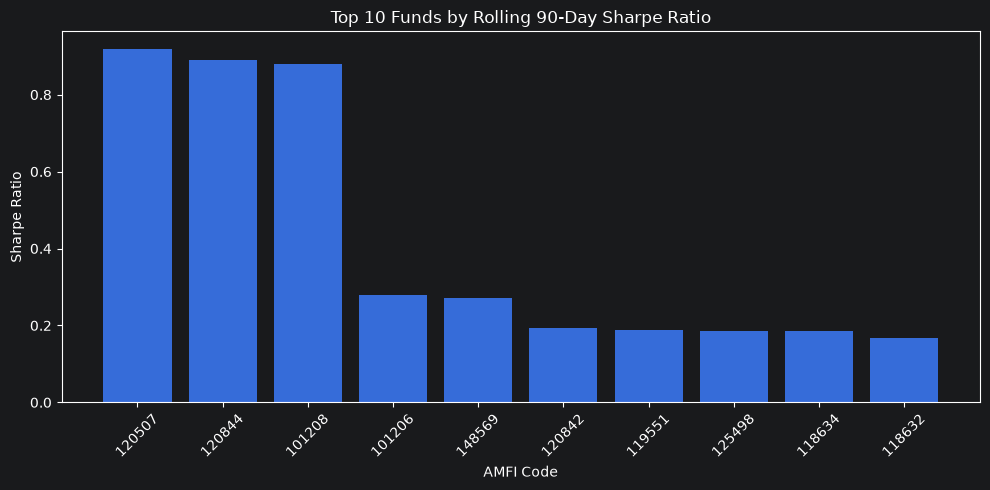

In [13]:
import matplotlib.pyplot as plt

top10 = latest_sharpe.head(10)

plt.figure(figsize=(10,5))
plt.bar(top10["amfi_code"].astype(str), top10["rolling_sharpe"])
plt.title("Top 10 Funds by Rolling 90-Day Sharpe Ratio")
plt.xlabel("AMFI Code")
plt.ylabel("Sharpe Ratio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
investors = pd.read_csv("../data/raw/08_investor_transactions.csv")

investors.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [15]:
cohort_age = investors.groupby("age_group")["amount_inr"].sum().sort_values(ascending=False)

cohort_age

age_group
26-35    1451600218
36-45     871647528
18-25     531639392
46-55     405406469
56+       261286823
Name: amount_inr, dtype: int64

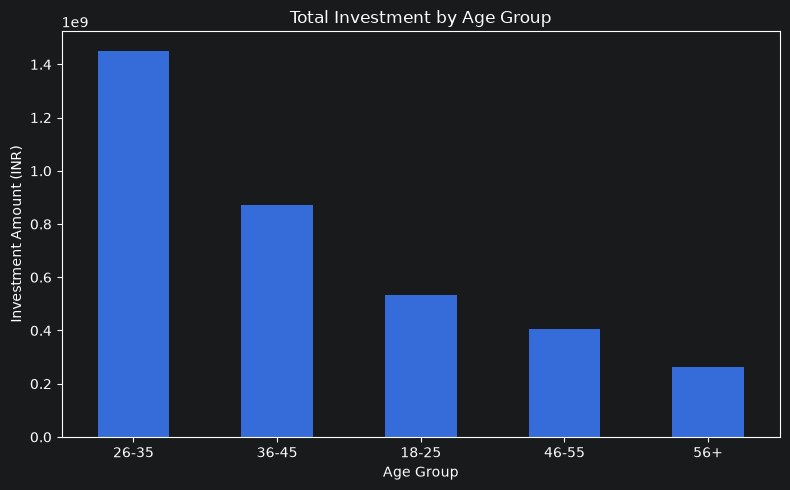

In [16]:
import matplotlib.pyplot as plt

cohort_age.plot(kind="bar", figsize=(8,5))

plt.title("Total Investment by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Investment Amount (INR)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [17]:
gender_investment = investors.groupby("gender")["amount_inr"].sum()

gender_investment

gender
Female    1176346701
Male      2345233729
Name: amount_inr, dtype: int64

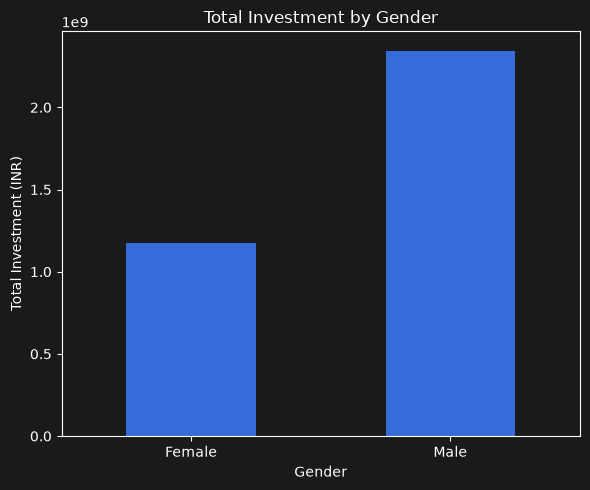

In [18]:
plt.figure(figsize=(6,5))
gender_investment.plot(kind="bar")

plt.title("Total Investment by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Investment (INR)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [19]:
income_investment = investors.groupby("annual_income_lakh")["amount_inr"].sum().sort_values(ascending=False)

income_investment.head(10)

annual_income_lakh
7.6     27797743
6.7     22930978
7.8     21614774
6.4     21541954
20.7    20854874
6.3     19961088
24.4    19242808
6.2     19097909
6.6     19023928
7.7     18691595
Name: amount_inr, dtype: int64

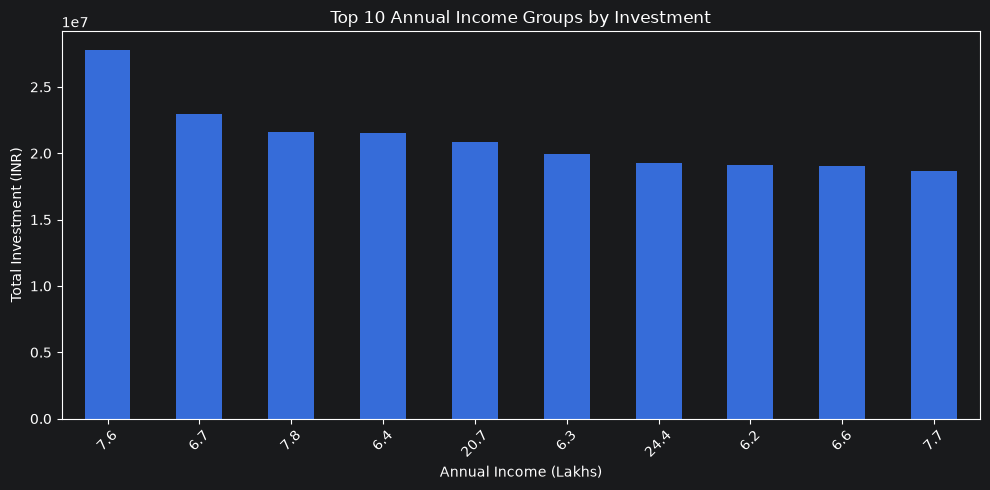

In [20]:
plt.figure(figsize=(10,5))

income_investment.head(10).plot(kind="bar")

plt.title("Top 10 Annual Income Groups by Investment")
plt.xlabel("Annual Income (Lakhs)")
plt.ylabel("Total Investment (INR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
sip = investors[investors["transaction_type"] == "SIP"]

sip_count = (
    sip.groupby("investor_id")["transaction_date"]
    .count()
    .reset_index(name="sip_count")
)

sip_count.head()

,investor_id,sip_count
0,INV000001,2
1,INV000002,3
2,INV000003,2
3,INV000004,6
4,INV000005,3


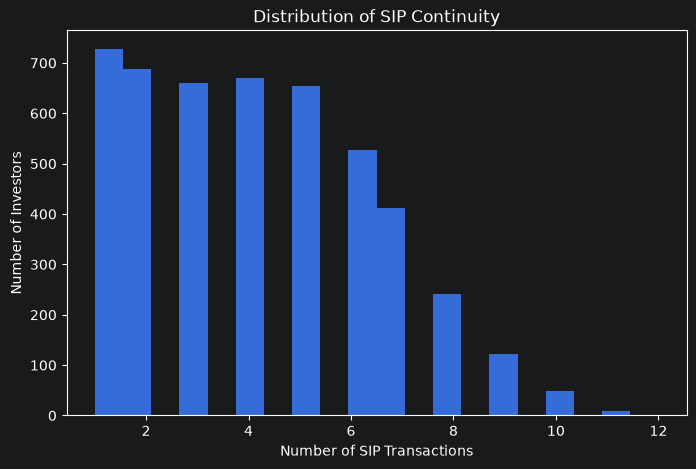

In [22]:
plt.figure(figsize=(8,5))

plt.hist(sip_count["sip_count"], bins=20)

plt.title("Distribution of SIP Continuity")
plt.xlabel("Number of SIP Transactions")
plt.ylabel("Number of Investors")

plt.show()

In [23]:
investors["transaction_date"] = pd.to_datetime(investors["transaction_date"])

investors["cohort_month"] = (
    investors.groupby("investor_id")["transaction_date"]
    .transform("min")
    .dt.to_period("M")
)

investors["transaction_month"] = investors["transaction_date"].dt.to_period("M")

investors.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_month,transaction_month
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024-01,2024-01
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024-01,2024-01
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024-01,2024-01
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024-01,2024-01
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024-01,2024-01


In [24]:
cohort = (
    investors.groupby(["cohort_month", "transaction_month"])["investor_id"]
    .nunique()
    .reset_index()
)

cohort.head()

,cohort_month,transaction_month,investor_id
0,2024-01,2024-01,1577
1,2024-01,2024-02,540
2,2024-01,2024-03,567
3,2024-01,2024-04,541
4,2024-01,2024-05,550


In [25]:
cohort_pivot = cohort.pivot(
    index="cohort_month",
    columns="transaction_month",
    values="investor_id"
)

cohort_pivot

transaction_month,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03,2025-04,2025-05
cohort_month,,,,,,,,,,,,,,,,,
2024-01,1577.0,540.0,567.0,541.0,550.0,565.0,546.0,548.0,523.0,566.0,544.0,551.0,572.0,518.0,537.0,545.0,586.0
2024-02,NaN,990.0,356.0,367.0,352.0,352.0,350.0,375.0,342.0,315.0,348.0,348.0,354.0,316.0,347.0,319.0,324.0
2024-03,NaN,NaN,669.0,209.0,235.0,248.0,213.0,209.0,209.0,213.0,205.0,215.0,232.0,184.0,226.0,231.0,209.0
2024-04,NaN,NaN,NaN,441.0,120.0,137.0,139.0,128.0,139.0,150.0,128.0,132.0,140.0,129.0,137.0,135.0,140.0
2024-05,NaN,NaN,NaN,NaN,294.0,77.0,105.0,88.0,76.0,78.0,80.0,102.0,89.0,75.0,89.0,80.0,85.0
2024-06,NaN,NaN,NaN,NaN,NaN,236.0,61.0,73.0,50.0,79.0,60.0,59.0,74.0,59.0,70.0,68.0,54.0
2024-07,NaN,NaN,NaN,NaN,NaN,NaN,175.0,45.0,40.0,41.0,43.0,36.0,40.0,36.0,41.0,38.0,37.0
2024-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,135.0,24.0,32.0,30.0,31.0,29.0,34.0,34.0,23.0,37.0
2024-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,17.0,19.0,22.0,21.0,20.0,13.0,19.0,19.0


In [28]:
import seaborn as sns
print(sns.__version__)

0.13.2


In [29]:
import seaborn as sns

In [31]:
investors = pd.read_csv("../data/raw/08_investor_transactions.csv")

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
cohort_pivot.head()

transaction_month,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03,2025-04,2025-05
cohort_month,,,,,,,,,,,,,,,,,
2024-01,1577.0,540.0,567.0,541.0,550.0,565.0,546.0,548.0,523.0,566.0,544.0,551.0,572.0,518.0,537.0,545.0,586.0
2024-02,NaN,990.0,356.0,367.0,352.0,352.0,350.0,375.0,342.0,315.0,348.0,348.0,354.0,316.0,347.0,319.0,324.0
2024-03,NaN,NaN,669.0,209.0,235.0,248.0,213.0,209.0,209.0,213.0,205.0,215.0,232.0,184.0,226.0,231.0,209.0
2024-04,NaN,NaN,NaN,441.0,120.0,137.0,139.0,128.0,139.0,150.0,128.0,132.0,140.0,129.0,137.0,135.0,140.0
2024-05,NaN,NaN,NaN,NaN,294.0,77.0,105.0,88.0,76.0,78.0,80.0,102.0,89.0,75.0,89.0,80.0,85.0


In [34]:
cohort_pivot.head()

transaction_month,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03,2025-04,2025-05
cohort_month,,,,,,,,,,,,,,,,,
2024-01,1577.0,540.0,567.0,541.0,550.0,565.0,546.0,548.0,523.0,566.0,544.0,551.0,572.0,518.0,537.0,545.0,586.0
2024-02,NaN,990.0,356.0,367.0,352.0,352.0,350.0,375.0,342.0,315.0,348.0,348.0,354.0,316.0,347.0,319.0,324.0
2024-03,NaN,NaN,669.0,209.0,235.0,248.0,213.0,209.0,209.0,213.0,205.0,215.0,232.0,184.0,226.0,231.0,209.0
2024-04,NaN,NaN,NaN,441.0,120.0,137.0,139.0,128.0,139.0,150.0,128.0,132.0,140.0,129.0,137.0,135.0,140.0
2024-05,NaN,NaN,NaN,NaN,294.0,77.0,105.0,88.0,76.0,78.0,80.0,102.0,89.0,75.0,89.0,80.0,85.0


In [35]:
investors.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [36]:
investors.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [37]:
investors["transaction_date"] = pd.to_datetime(investors["transaction_date"])

investors["transaction_month"] = investors["transaction_date"].dt.to_period("M")

investors["cohort_month"] = investors.groupby("investor_id")["transaction_month"].transform("min")

In [38]:
investors.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,transaction_month,cohort_month
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024-01,2024-01
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024-01,2024-01
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024-01,2024-01
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024-01,2024-01
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024-01,2024-01


In [39]:
print(investors.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status', 'transaction_month', 'cohort_month']


In [41]:
cohort = (
    investors.groupby(["cohort_month", "transaction_month"])["investor_id"]
    .nunique()
    .reset_index()
)

In [42]:
cohort.head()

,cohort_month,transaction_month,investor_id
0,2024-01,2024-01,1577
1,2024-01,2024-02,540
2,2024-01,2024-03,567
3,2024-01,2024-04,541
4,2024-01,2024-05,550


In [43]:
cohort_pivot = cohort.pivot(
    index="cohort_month",
    columns="transaction_month",
    values="investor_id"
)

In [44]:
cohort_pivot.head()

transaction_month,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03,2025-04,2025-05
cohort_month,,,,,,,,,,,,,,,,,
2024-01,1577.0,540.0,567.0,541.0,550.0,565.0,546.0,548.0,523.0,566.0,544.0,551.0,572.0,518.0,537.0,545.0,586.0
2024-02,NaN,990.0,356.0,367.0,352.0,352.0,350.0,375.0,342.0,315.0,348.0,348.0,354.0,316.0,347.0,319.0,324.0
2024-03,NaN,NaN,669.0,209.0,235.0,248.0,213.0,209.0,209.0,213.0,205.0,215.0,232.0,184.0,226.0,231.0,209.0
2024-04,NaN,NaN,NaN,441.0,120.0,137.0,139.0,128.0,139.0,150.0,128.0,132.0,140.0,129.0,137.0,135.0,140.0
2024-05,NaN,NaN,NaN,NaN,294.0,77.0,105.0,88.0,76.0,78.0,80.0,102.0,89.0,75.0,89.0,80.0,85.0


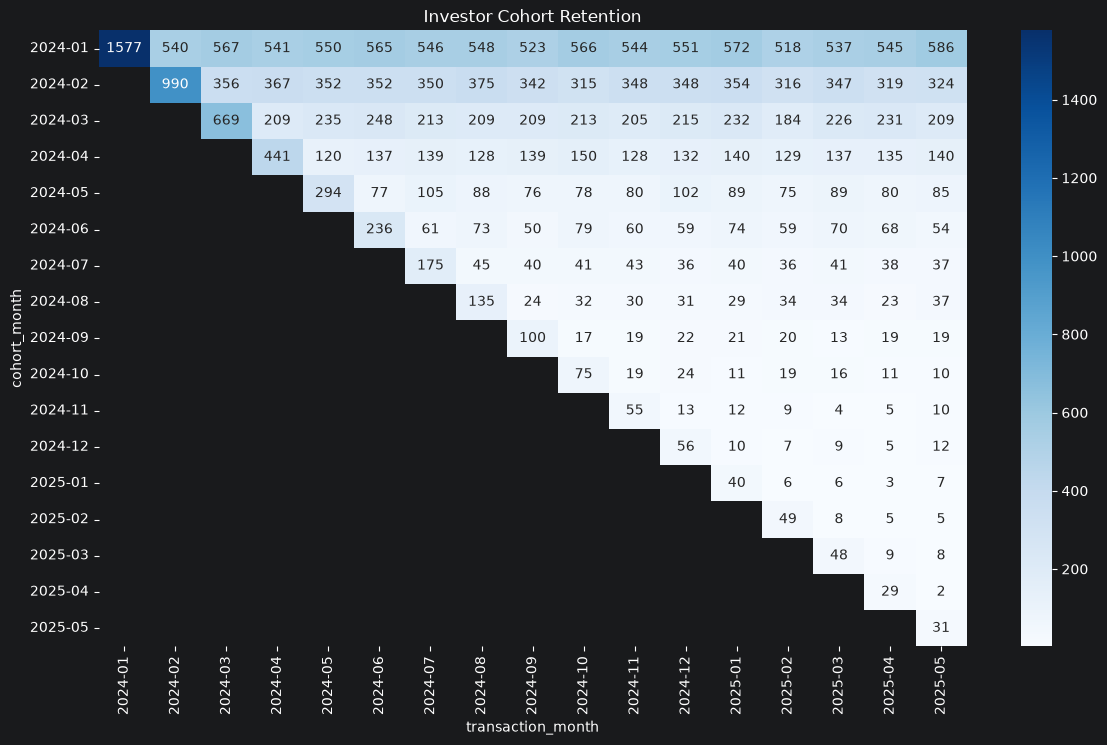

In [45]:
plt.figure(figsize=(14,8))

sns.heatmap(
    cohort_pivot,
    annot=True,
    fmt=".0f",
    cmap="Blues"
)

plt.title("Investor Cohort Retention")
plt.show()